# Segment Clique Statistics

This notebook is for analyzing the segment clique annotations and to get some statistics

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import json
import math
import csv
import json
from pathlib import Path
from collections import defaultdict
import random

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import Audio, display, YouTubeVideo, HTML

In [2]:
cliques_json_path = Path(
    "/projects/mtg/projects/version-identification/datasets/Discogs-VI/dataset_release/discogs_20240701/main/Discogs-VI-YT-20240701-light.json.train"
)
with open(cliques_json_path) as f:
    cliques = json.load(f)
print(len(cliques))

v_id_yt_id = {v["version_id"]: v["youtube_id"] for versions in cliques.values() for v in versions}

80017


In [3]:
# This csv is small enough to fit to memory
csv_path = Path(
    "/projects/mtg/projects/unified-similarity/dvi-similar-regions/Discogs-VI-SIREN/train/segment-cliques.csv"
)
df = pd.read_csv(csv_path)
df = df.sort_values(['track_clique_id', 'segment_clique_id', 'version_id'])
print(f"{len(df):,}")
display(df.head())

18,566,717


,track_clique_id,segment_clique_id,version_id,youtube_id,segment_start_time,segment_end_time,track_duration
17567298,C-0000000,S-0492995,V-0000004,MI23duPUNaY,19.0,39.0,216.399994
17567300,C-0000000,S-0492995,V-0000004,MI23duPUNaY,46.0,66.0,216.399994
17567301,C-0000000,S-0492995,V-0000004,MI23duPUNaY,85.0,105.0,216.399994
17567303,C-0000000,S-0492995,V-0000004,MI23duPUNaY,93.0,113.0,216.399994
17567305,C-0000000,S-0492995,V-0000004,MI23duPUNaY,10.0,30.0,216.399994


In [4]:
# Entire discogs-vi-yt
clique_ids = set(cliques.keys())
print(f'{len(clique_ids):,}')

# Track cliques that survive the similar region finding algorithm
df_clique_ids = set(df["track_clique_id"].to_list())
print(f'{len(df_clique_ids):,}')

print(f'{len(clique_ids) - len(df_clique_ids):,} track cliques lost.')

print(f'{df["segment_clique_id"].nunique():,} segment cliques in total.')

80,017
73,887
6,130 track cliques lost.
643,932 segment cliques in total.


In [15]:
tot = 0
for clique_id in df_clique_ids:
    tot += len(list(combinations(cliques[clique_id], 2)))
print(f"{tot:,}")

3,522,419


In [5]:
df["version_id"].value_counts().head(100)

version_id
V-0367730    575
V-0367753    559
V-0673662    554
V-0325833    538
V-0367729    534
            ... 
V-0673013    364
V-0625609    363
V-0478550    363
V-0588499    363
V-0709549    362
Name: count, Length: 100, dtype: int64

In [6]:
df["version_id"].value_counts().tail(100)

version_id
V-0121034    1
V-1806353    1
V-0068559    1
V-0933284    1
V-1324810    1
            ..
V-0213366    1
V-1808409    1
V-0901860    1
V-0213044    1
V-0213144    1
Name: count, Length: 100, dtype: int64

In [7]:
df.groupby("segment_clique_id")["version_id"].nunique().sort_values(ascending=False)

segment_clique_id
S-0643723    445
S-0643747    401
S-0643786    378
S-0643580    353
S-0643696    350
            ... 
S-0275607      2
S-0275608      2
S-0275609      2
S-0275612      2
S-0275602      2
Name: version_id, Length: 643932, dtype: int64

In [8]:
df["track_duration"].describe()

count    1.856672e+07
mean     2.362289e+02
std      1.046510e+02
min      2.010000e+01
25%      1.689000e+02
50%      2.049000e+02
75%      2.721000e+02
max      1.192800e+03
Name: track_duration, dtype: float64

In [9]:
(df["segment_end_time"] - df["segment_start_time"]).describe(
    percentiles=np.arange(6)/100
)

count    18566717.0
mean           20.0
std             0.0
min            20.0
0%             20.0
1%             20.0
2%             20.0
3%             20.0
4%             20.0
5%             20.0
50%            20.0
max            20.0
dtype: float64

## Apperance per segment clique

In [10]:
n_appearances = df.groupby(["segment_clique_id", "version_id"]).size()
n_appearances

segment_clique_id  version_id
S-0000000          V-0056332     104
                   V-0056335     133
                   V-0056338      91
                   V-0056339     182
                   V-0056341     119
                                ... 
S-0643929          V-0210500       1
S-0643930          V-0210510       1
                   V-0210610       1
S-0643931          V-0210577       1
                   V-0210635       1
Length: 1564021, dtype: int64

In [11]:
max_key = n_appearances.idxmax()      # tuple: (segment_clique_id, version_id)
max_n   = n_appearances.loc[max_key]  # the count
print(max_key, max_n)

seg_id, ver_id = max_key
rows_max = df[(df["segment_clique_id"] == seg_id) & (df["version_id"] == ver_id)]

rows_max = rows_max.sort_values("segment_start_time", ascending=True).reset_index(drop=True)
display(rows_max)

('S-0001540', 'V-0367730') 575


,track_clique_id,segment_clique_id,version_id,youtube_id,segment_start_time,segment_end_time,track_duration
0,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,0.0,20.0,791.900024
1,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,1.0,21.0,791.900024
2,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,2.0,22.0,791.900024
3,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,3.0,23.0,791.900024
4,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,4.0,24.0,791.900024
...,...,...,...,...,...,...,...
570,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,762.0,782.0,791.900024
571,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,763.0,783.0,791.900024
572,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,764.0,784.0,791.900024
573,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,765.0,785.0,791.900024


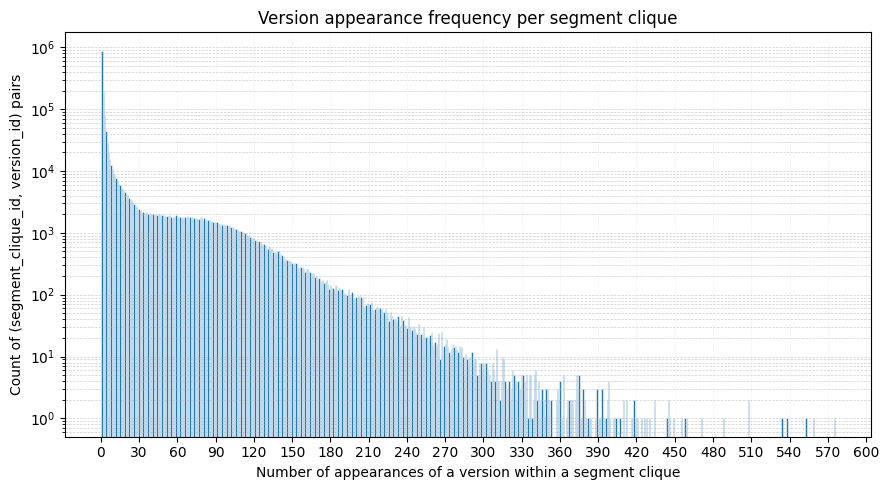

In [12]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(9, 5))

bins = np.arange(n_appearances.min(), n_appearances.max() + 2) - 0.5  # centered integer bins
ax.hist(n_appearances, bins=bins, edgecolor="white", linewidth=0.4)

ax.set_yscale("log")
ax.set_xlabel("Number of appearances of a version within a segment clique")
ax.set_ylabel("Count of (segment_clique_id, version_id) pairs")
ax.set_title("Version appearance frequency per segment clique")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=25))
ax.grid(axis="y", which="both", linestyle="--", linewidth=0.5, alpha=0.6)
ax.grid(axis="x", which="major", linestyle=":", linewidth=0.4, alpha=0.4)

plt.tight_layout()
plt.show()

In [13]:
with pd.option_context(
    "display.max_rows", 200,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(rows_max.head(200))

,track_clique_id,segment_clique_id,version_id,youtube_id,segment_start_time,segment_end_time,track_duration
0,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,0.0,20.0,791.900024
1,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,1.0,21.0,791.900024
2,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,2.0,22.0,791.900024
3,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,3.0,23.0,791.900024
4,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,4.0,24.0,791.900024
5,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,5.0,25.0,791.900024
6,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,6.0,26.0,791.900024
7,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,8.0,28.0,791.900024
8,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,9.0,29.0,791.900024
9,C-0039870,S-0001540,V-0367730,Iay3hWYXyRQ,10.0,30.0,791.900024
